Philipp M. Srivastava <br />
Sample Reading of High Mass Data <br />
2025-07-14


In [12]:
import numpy as np
import scienceplots
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl


plt.style.use(['science', "ieee", "no-latex"]) # if you don't have LaTeX installed

mpl.rcParams.update({
    'text.usetex': False,        # explicitly disable LaTeX
    'mathtext.fontset': 'stix',  # best-looking mathtext font, close to LaTeX
    'font.family': 'STIXGeneral',
})

Reading in NumPy File

In [3]:
sim = np.load("./01650M_dir.npy", allow_pickle=True)

In [14]:
df = pd.DataFrame(sim)
display(df.head())

,initial_mass,initial_z,star_age,mass,logR,logP,logRho,logT,luminosity,opacity,x_mass_fraction_H,y_mass_fraction_He,z_mass_fraction_metals,eps_nuc,eps_nuc_neu_total,eps_grav_nh,eps_grav,zone,q
0,16.5,0.02,1.124803e+07,15.672543,2.769037,2.632306,-8.726443,3.565941,56927.325018,0.001937,0.667269,0.319678,0.013054,0.042915,1.739978e-29,-0.003933,-2.621206,1.0,1.0
1,16.5,0.02,1.124803e+07,15.672543,2.769037,2.632306,-8.726443,3.565941,56927.325018,0.001937,0.667269,0.319678,0.013054,0.042915,1.739978e-29,-0.003933,-2.621206,2.0,1.0
2,16.5,0.02,1.124803e+07,15.672543,2.769037,2.632306,-8.726443,3.565941,56927.325018,0.001937,0.667269,0.319678,0.013054,0.042915,1.739978e-29,-0.003933,-2.621206,3.0,1.0
3,16.5,0.02,1.124803e+07,15.672543,2.769037,2.632306,-8.726443,3.565941,56927.325018,0.001937,0.667269,0.319678,0.013054,0.042915,1.739978e-29,-0.003933,-2.621205,4.0,1.0
4,16.5,0.02,1.124803e+07,15.672543,2.769037,2.632306,-8.726443,3.565941,56927.325018,0.001937,0.667269,0.319678,0.013054,0.042915,1.739978e-29,-0.003933,-2.621205,5.0,1.0


Tips:

- Use `sim.dtype.names` to get a lost of columns
- Each row is a zone or shell of the star. We need to arrange the zones by profile, which we are doing in the `process_simulation` function
- The quantities we are most interested in are `"logR"`, `"logP"`, `"logT"`, and `"luminosity"`. 
- `"mass"` is used as the independent variable, but you could also use `"logR"` instead

In [4]:

def process_simulation(sim):
    """ This function processes a simulation into 
        a list of profiles.

        Parameter(s):
            sim - a loaded numpy structured array which has all of the zones
                  of a simulation for a spatio-temporal evolution as rows

        Return Value(s):
            ages - a list of ages corresponding to each profile
            profiles - the profiles
    """
    zone_starts = np.where(sim["zone"] == 1.0)[0] # finding all zones at interior or exterior of star (depends on setup)

    profiles = []
    ages = []

    for i, start in enumerate(zone_starts):
        if i < len(zone_starts) - 1:
            profiles.append(
                sim[start:zone_starts[i + 1]] # getting zones belonging to profile
            )

        else:
            profiles.append(
                sim[start:] # edge case for last zone
            )

        ages.append(
            sim[start]["star_age"] # collecting ages
        )

    ages = np.array(ages)

    # ordering profiles by age
    ordered_inds = ages.argsort()
    profiles = np.array(profiles, dtype = object)
    profiles = profiles[ordered_inds]
    ages = ages[ordered_inds]

    return ages, profiles

Processing simulation into profiles

In [5]:
age, profs = process_simulation(sim)

Plotting profile to see if it went well

In [6]:
profs[0].dtype.names

('initial_mass',
 'initial_z',
 'star_age',
 'mass',
 'logR',
 'logP',
 'logRho',
 'logT',
 'luminosity',
 'opacity',
 'x_mass_fraction_H',
 'y_mass_fraction_He',
 'z_mass_fraction_metals',
 'eps_nuc',
 'eps_nuc_neu_total',
 'eps_grav_nh',
 'eps_grav',
 'zone',
 'q')

Text(0.5, 1.0, 'Luminosity Profile')

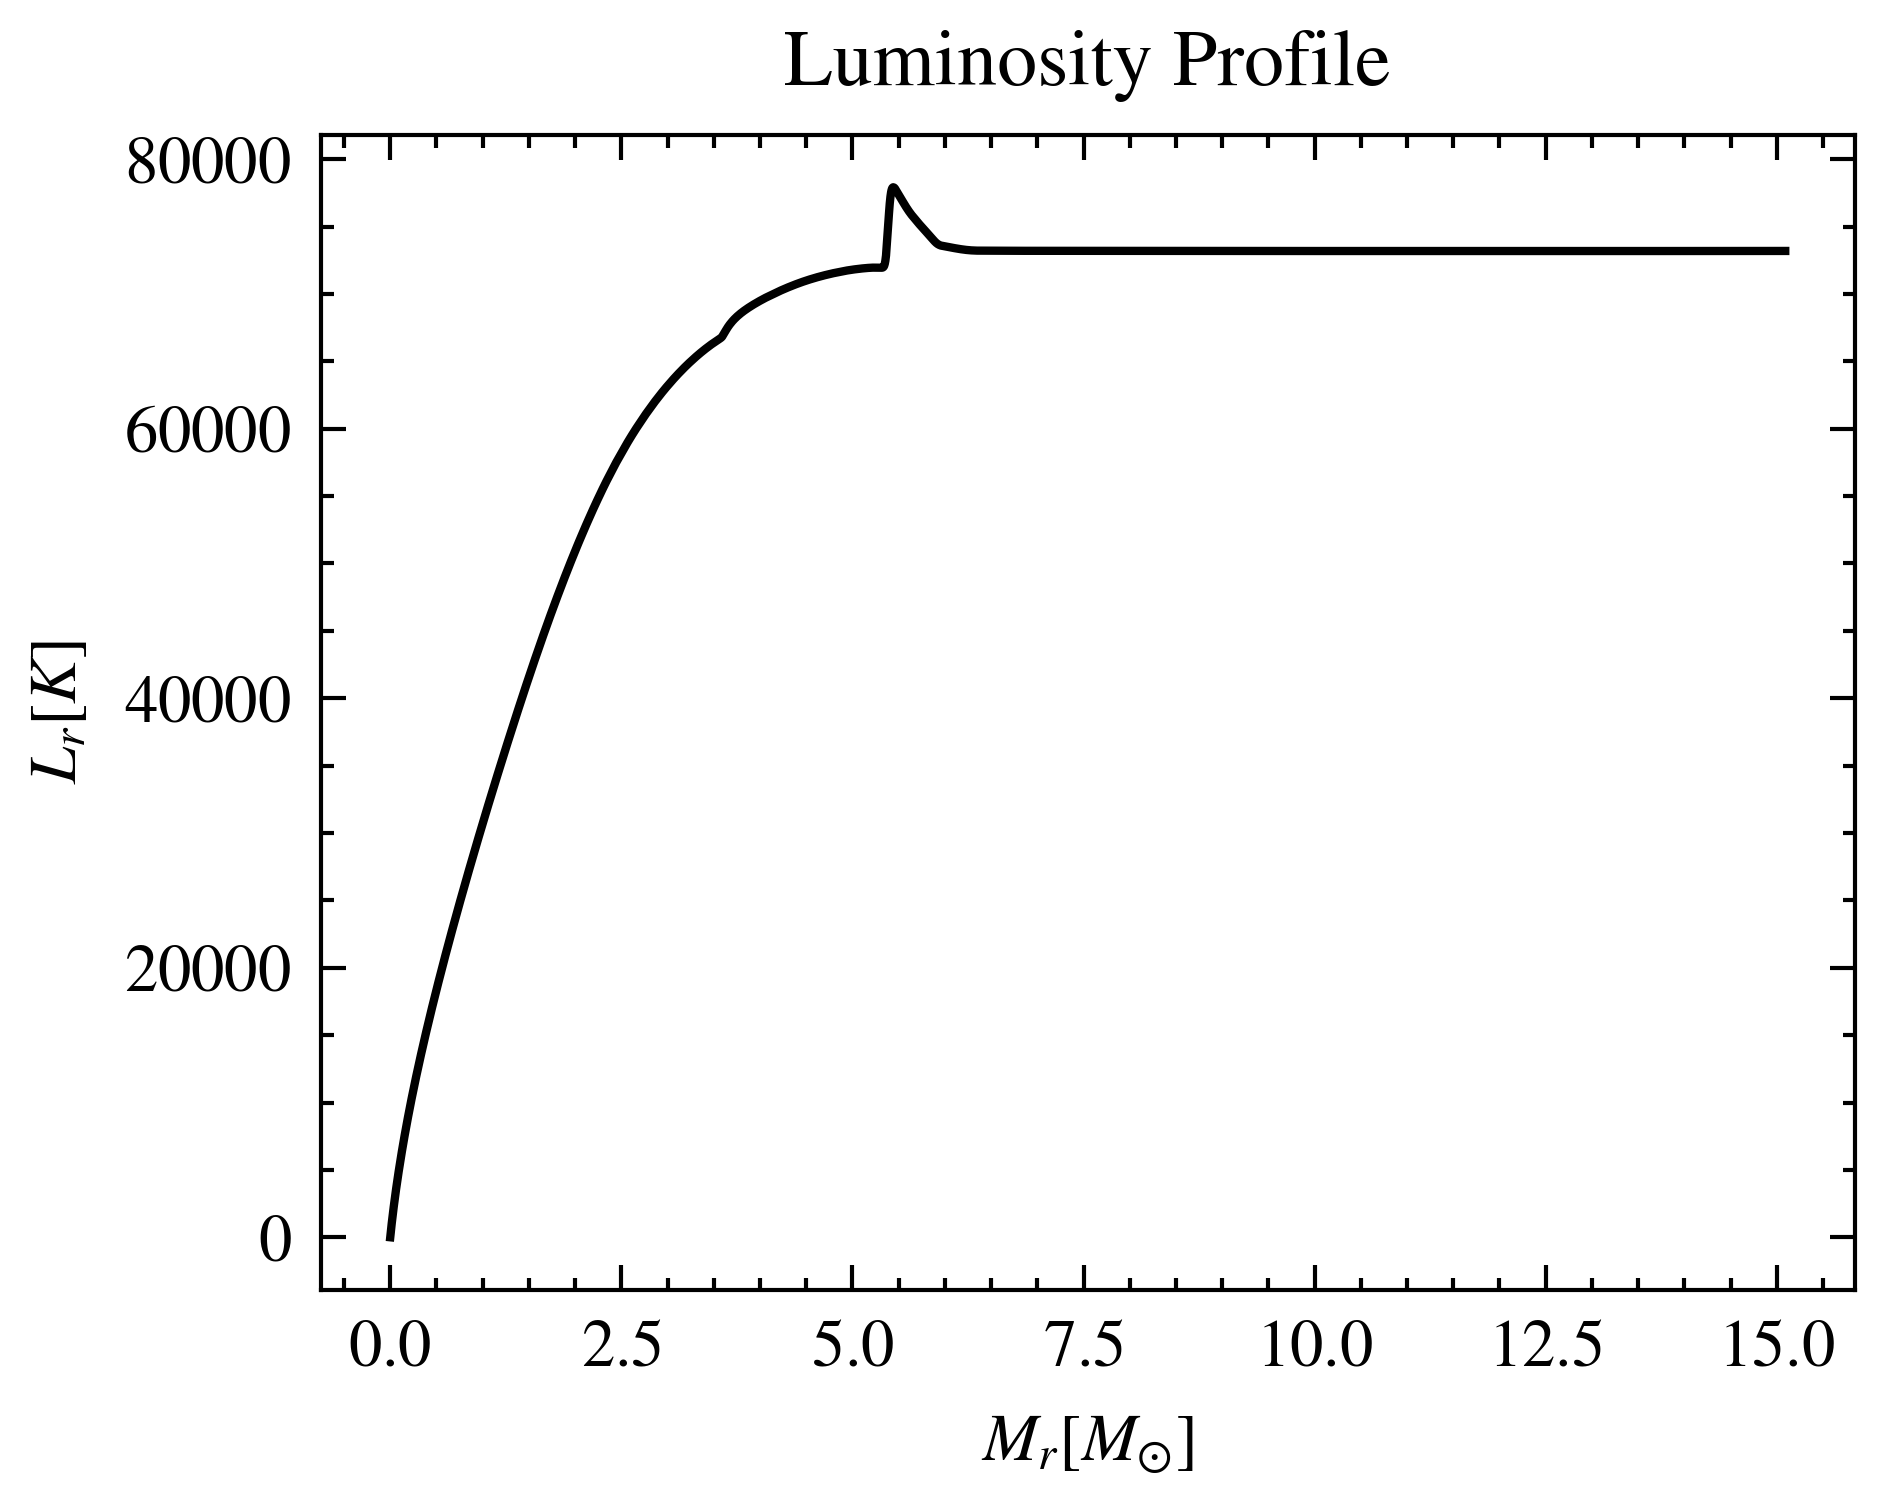

In [7]:
idx = -1
plt.plot(profs[idx]["mass"], profs[idx]["luminosity"])
plt.xlabel(r"$M_r [M_{\odot}]$")
plt.ylabel(r"$L_r[K]$")
plt.title("Luminosity Profile")